# 02 Funnel analysis

Where sessions are lost between arriving and paying, and which segments lose them fastest.

The funnel is measured on sessions rather than users. A user can browse on Monday and buy on Thursday, so a user level funnel hides the step that actually broke. Session level also matches how the checkout flow is experienced.

Steps are cumulative: a session counted at checkout is also counted at add to cart.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ga4_growth import metrics, stats, viz
from ga4_growth.warehouse import query

viz.setup()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

## The whole funnel

In [2]:
funnel = metrics.funnel_overall()
funnel.style.format({
    "sessions": "{:,.0f}", "dropped": "{:,.0f}",
    "step_conversion": "{:.2%}", "cumulative_conversion": "{:.2%}", "drop_off_rate": "{:.2%}",
})

,step,sessions,step_order,step_conversion,cumulative_conversion,dropped,drop_off_rate
0,Session,"228,210",0,nan%,100.00%,nan,nan%
1,Product view,"144,280",1,63.22%,63.22%,"83,930",36.78%
2,Add to cart,"20,991",2,14.55%,9.20%,"123,289",85.45%
3,View cart,"16,623",3,79.19%,7.28%,"4,368",20.81%
4,Begin checkout,"7,685",4,46.23%,3.37%,"8,938",53.77%
5,Shipping info,"6,243",5,81.24%,2.74%,"1,442",18.76%
6,Payment info,"5,298",6,84.86%,2.32%,945,15.14%
7,Purchase,"4,492",7,84.79%,1.97%,806,15.21%


'reports\\figures\\02_funnel_overall.png'

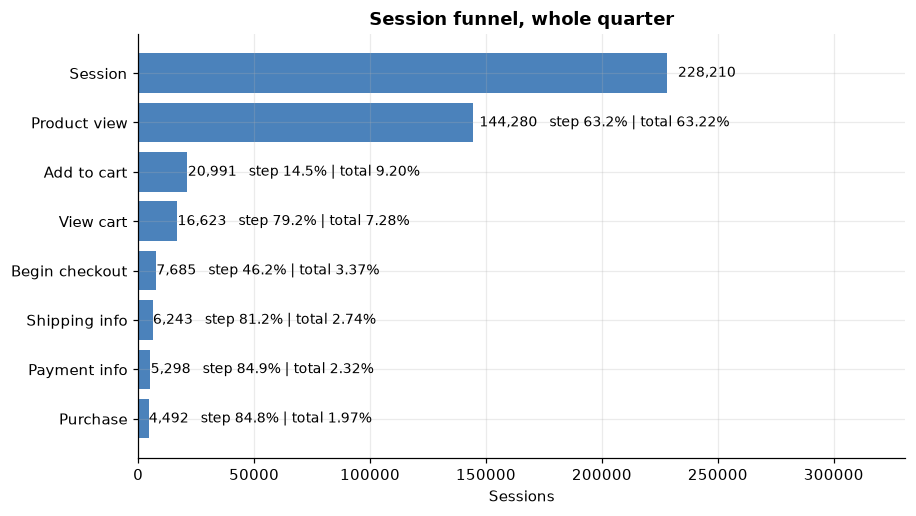

In [3]:
viz.save(viz.funnel_chart(funnel, "Session funnel, whole quarter"), "02_funnel_overall")

In [4]:
# Ranking the steps by how many sessions each one costs. Percentages alone push
# attention to the bottom of the funnel where the volume is small.
loss = funnel.dropna(subset=["dropped"]).copy()
loss["share_of_total_loss"] = loss["dropped"] / loss["dropped"].sum()
loss[["step", "dropped", "drop_off_rate", "share_of_total_loss"]].sort_values("dropped", ascending=False)

,step,dropped,drop_off_rate,share_of_total_loss
2,Add to cart,123289.0,0.854512,0.551091
1,Product view,83930.0,0.367775,0.375160
4,Begin checkout,8938.0,0.537689,0.039952
3,View cart,4368.0,0.208089,0.019525
5,Shipping info,1442.0,0.187638,0.006446
6,Payment info,945.0,0.151370,0.004224
7,Purchase,806.0,0.152133,0.003603


## Funnel by segment

Same funnel cut by the dimensions a product team can actually act on.

In [5]:
rate_cols = ["segment", "sessions", "product_view_rate", "view_to_cart_rate", "cart_to_checkout_rate",
             "shipping_to_payment_rate", "checkout_to_purchase_rate", "session_conversion_rate",
             "revenue_per_session"]

device = metrics.funnel_by("device_category")
device[rate_cols].round(4)

,segment,sessions,product_view_rate,view_to_cart_rate,cart_to_checkout_rate,shipping_to_payment_rate,checkout_to_purchase_rate,session_conversion_rate,revenue_per_session
0,mobile,111514,0.6170,0.1368,0.3323,0.7937,0.5216,0.0146,1.0190
1,desktop,100834,0.6496,0.1547,0.4000,0.8887,0.6330,0.0254,1.7701
2,tablet,15862,0.6289,0.1445,0.3484,0.8568,0.5857,0.0185,1.2840


In [6]:
channel = metrics.funnel_by("channel_group")
channel[rate_cols].round(4)

,segment,sessions,product_view_rate,view_to_cart_rate,cart_to_checkout_rate,shipping_to_payment_rate,checkout_to_purchase_rate,session_conversion_rate,revenue_per_session
0,Paid,79635,0.5929,0.1294,0.3625,0.8494,0.5959,0.0166,1.1378
1,Organic Search,59594,0.6492,0.1398,0.3449,0.8476,0.5716,0.0179,1.2770
2,Direct,52213,0.6787,0.1642,0.3907,0.8419,0.5816,0.0253,1.7129
3,Referral,16928,0.5405,0.0834,0.3303,0.8513,0.5714,0.0085,0.6494
4,Email,12642,0.7273,0.2219,0.4196,0.8724,0.5993,0.0406,2.8545
5,Affiliate,7198,0.6386,0.1851,0.2632,0.8287,0.5670,0.0176,1.2852


In [7]:
user_type = metrics.funnel_by("user_type")
user_type[rate_cols].round(4)

,segment,sessions,product_view_rate,view_to_cart_rate,cart_to_checkout_rate,shipping_to_payment_rate,checkout_to_purchase_rate,session_conversion_rate,revenue_per_session
0,New,150000,0.5849,0.1181,0.3215,0.8231,0.5230,0.0116,0.8179
1,Returning,78210,0.7230,0.1880,0.4096,0.8667,0.6316,0.0352,2.4268


In [8]:
price = metrics.funnel_by("price_band").query("segment != 'No product view'").sort_values("segment")
price[rate_cols].round(4)

,segment,sessions,product_view_rate,view_to_cart_rate,cart_to_checkout_rate,shipping_to_payment_rate,checkout_to_purchase_rate,session_conversion_rate,revenue_per_session
4,1. Under $15,6601,1.0,0.1809,0.3224,0.8723,0.6156,0.0359,0.6260
2,2. $15-30,57857,1.0,0.1590,0.3707,0.8438,0.5836,0.0344,1.4910
1,3. $30-60,61714,1.0,0.1385,0.3671,0.8499,0.5792,0.0294,2.6162
3,4. $60-100,15919,1.0,0.1165,0.3677,0.8582,0.5953,0.0255,3.2796
5,5. $100+,2189,1.0,0.0900,0.3604,0.8033,0.5915,0.0192,3.8458


'reports\\figures\\02_country_and_category.png'

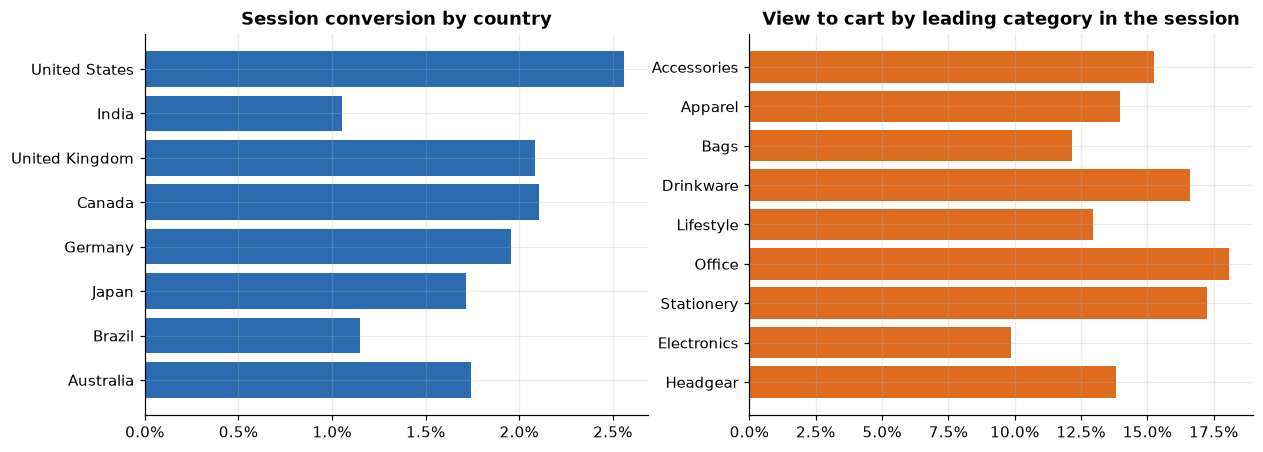

In [9]:
country = metrics.funnel_by("country").head(8)
# Sessions that never opened a product page have no leading category, so that
# group is dropped instead of being drawn as an unlabelled bar.
category = metrics.funnel_by("primary_category").dropna(subset=["segment"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(country["segment"][::-1], country["session_conversion_rate"][::-1], color=viz.PALETTE[0])
axes[0].set_title("Session conversion by country")
axes[0].xaxis.set_major_formatter(lambda v, _: f"{v:.1%}")
axes[1].barh(category["segment"][::-1], category["view_to_cart_rate"][::-1], color=viz.PALETTE[1])
axes[1].set_title("View to cart by leading category in the session")
axes[1].xaxis.set_major_formatter(lambda v, _: f"{v:.1%}")
viz.save(fig, "02_country_and_category")

## Bottleneck 1: product view to add to cart

By volume this is the largest loss in the funnel. It is worth splitting because two very different things are mixed inside it: people who never intended to buy, and people who wanted to buy but were put off by the item.

In [10]:
# Cart rate against how many products the session looked at. Deeper browsing is
# a sign of intent, so if the rate stays flat the problem is the product page,
# not the audience.
query("""
SELECT products_viewed,
       count(*)                                                    AS sessions,
       round(count(*) FILTER (WHERE added_to_cart) / count(*), 4)   AS view_to_cart_rate,
       round(count(*) FILTER (WHERE purchased) / count(*), 4)       AS session_conversion_rate
FROM fct_funnel
WHERE viewed_product
GROUP BY 1
HAVING count(*) > 500
ORDER BY 1
""")

,products_viewed,sessions,view_to_cart_rate,session_conversion_rate
0,1,37524,0.1503,0.0322
1,2,38518,0.1458,0.0307
2,3,38818,0.1429,0.0309
3,4,29420,0.1424,0.0307


'reports\\figures\\02_price_band.png'

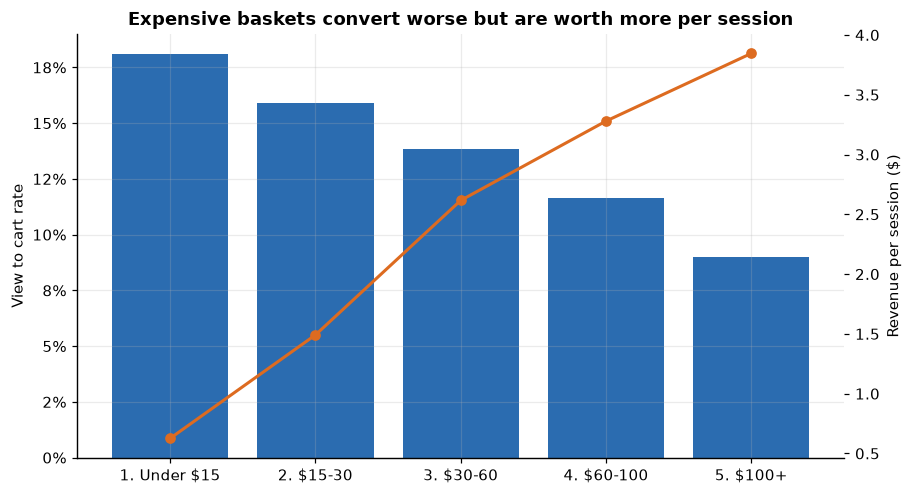

In [11]:
# Price is the other half of the story. Cart rate falls as the basket gets more
# expensive, but revenue per session goes the other way.
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(price["segment"], price["view_to_cart_rate"], color=viz.PALETTE[0], label="view to cart")
ax.set_ylabel("View to cart rate")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2 = ax.twinx()
ax2.plot(price["segment"], price["revenue_per_session"], color=viz.PALETTE[1], marker="o", lw=2)
ax2.set_ylabel("Revenue per session ($)")
ax2.grid(False)
ax.set_title("Expensive baskets convert worse but are worth more per session")
viz.save(fig, "02_price_band")

## Bottleneck 2: cart to checkout

Sessions that added an item and then did not start checkout. This is the step where the site has already earned intent and still loses it.

In [12]:
query("""
SELECT
  count(*)                                                       AS cart_sessions,
  count(*) FILTER (WHERE NOT began_checkout)                     AS abandoned_before_checkout,
  round(count(*) FILTER (WHERE NOT began_checkout) / count(*), 4) AS cart_abandonment_rate,
  round(avg(products_viewed) FILTER (WHERE NOT began_checkout), 2) AS products_viewed_abandoners,
  round(avg(products_viewed) FILTER (WHERE began_checkout), 2)     AS products_viewed_continuers,
  round(avg(session_duration_sec) FILTER (WHERE NOT began_checkout), 0) AS seconds_abandoners,
  round(avg(session_duration_sec) FILTER (WHERE began_checkout), 0)     AS seconds_continuers
FROM fct_funnel
WHERE added_to_cart
""")

,cart_sessions,abandoned_before_checkout,cart_abandonment_rate,products_viewed_abandoners,products_viewed_continuers,seconds_abandoners,seconds_continuers
0,20991,13306,0.6339,2.38,2.41,323.0,612.0


In [13]:
# Cart abandonment split by channel and by whether the user had been on the site
# before. New users from paid channels abandon most.
abandon = query("""
SELECT channel_group, user_type,
       count(*)                                                        AS cart_sessions,
       round(1 - count(*) FILTER (WHERE began_checkout) / count(*), 4)  AS cart_abandonment_rate
FROM fct_funnel
WHERE added_to_cart
GROUP BY 1, 2
HAVING count(*) > 200
ORDER BY cart_abandonment_rate DESC
""")
abandon.pivot(index="channel_group", columns="user_type", values="cart_abandonment_rate")

user_type,New,Returning
channel_group,,
Affiliate,0.7519,0.7239
Direct,0.6584,0.5629
Email,0.6242,0.5434
Organic Search,0.6960,0.6136
Paid,0.6820,0.5930
Referral,0.7260,0.5982


## Bottleneck 3: shipping info to payment info on mobile

This step is nearly free on desktop and expensive on mobile. It is also the one step where the drop and the time spent on it point at the same cause.

In [14]:
step_test = stats.compare_segments(
    metrics.funnel_by("device_category", min_sessions=0),
    label_col="segment", success_col="added_payment", total_col="added_shipping",
    baseline="desktop",
)
step_test.round(4)

,label,baseline,rate_a,rate_b,absolute_diff,relative_lift,z_stat,p_value,ci_low,ci_high,p_adjusted,significant
0,mobile,desktop,0.8887,0.7937,-0.0950,-0.1069,-10.0060,0.0000,-0.1141,-0.0759,0.0000,True
1,tablet,desktop,0.8887,0.8568,-0.0319,-0.0359,-1.9022,0.0572,-0.0676,0.0038,0.0572,False


In [15]:
# Time spent on each checkout step. Mobile users are not dropping out because
# they lost interest, they are spending noticeably longer on the payment step.
metrics.checkout_timing()

,device_category,checkouts,median_cart_to_checkout,median_shipping_to_payment,median_checkout_to_purchase
0,desktop,4054,184.0,90.0,232.0
1,mobile,3129,182.0,160.0,304.0
2,tablet,502,183.0,89.0,229.5


'reports\\figures\\02_device_step_rates.png'

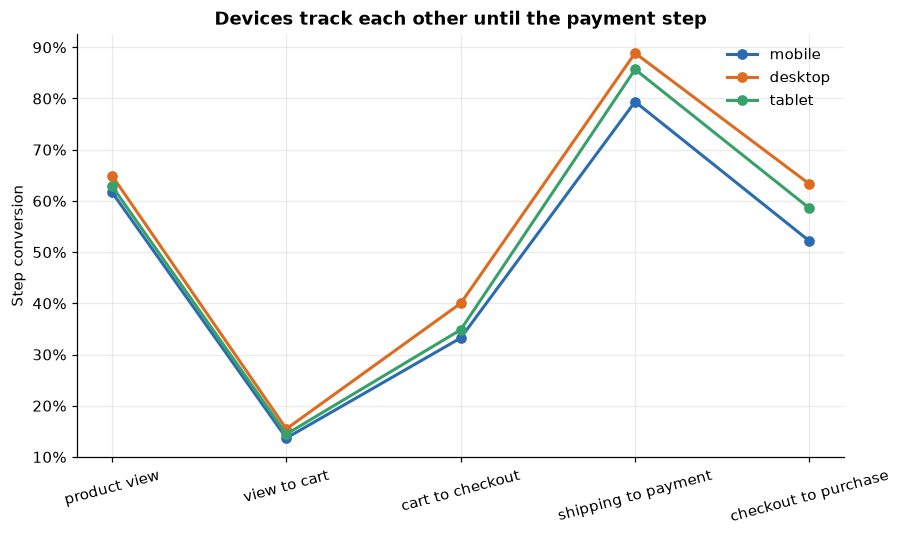

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
steps = ["product_view_rate", "view_to_cart_rate", "cart_to_checkout_rate",
         "shipping_to_payment_rate", "checkout_to_purchase_rate"]
x = np.arange(len(steps))
for i, (_, row) in enumerate(device.iterrows()):
    ax.plot(x, [row[s] for s in steps], marker="o", lw=2, color=viz.PALETTE[i], label=row["segment"])
ax.set_xticks(x, [s.replace("_rate", "").replace("_", " ") for s in steps], rotation=15)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("Step conversion")
ax.set_title("Devices track each other until the payment step")
ax.legend(frameon=False)
viz.save(fig, "02_device_step_rates")

In [17]:
# How much revenue is on the table if mobile matched desktop on that one step,
# holding everything downstream the same.
row = device.set_index("segment")
gap = row.loc["desktop", "shipping_to_payment_rate"] - row.loc["mobile", "shipping_to_payment_rate"]
extra_payments = row.loc["mobile", "added_shipping"] * gap
pay_to_purchase = row.loc["mobile", "purchased"] / row.loc["mobile", "added_payment"]
aov = metrics.headline_kpis()["average_order_value"]

pd.Series({
    "mobile sessions reaching shipping info": row.loc["mobile", "added_shipping"],
    "gap vs desktop on shipping to payment": round(gap, 4),
    "extra payment steps completed": round(extra_payments),
    "extra orders per quarter": round(extra_payments * pay_to_purchase),
    "extra revenue per quarter ($)": round(extra_payments * pay_to_purchase * aov),
}).to_frame("if mobile matched desktop")

,if mobile matched desktop
mobile sessions reaching shipping info,2496.000
gap vs desktop on shipping to payment,0.095
extra payment steps completed,237.000
extra orders per quarter,195.000
extra revenue per quarter ($),13591.000


## Device and channel together

Channel quality and device mix are correlated, so neither cut alone proves much. The interaction is checked before any of it is written up as a finding, and again with a regression in notebook 04.

device_category,desktop,mobile,tablet
channel_group,,,
Affiliate,0.0221,0.0141,NaN
Direct,0.0325,0.0185,0.0267
Email,0.0489,0.0332,NaN
Organic Search,0.0238,0.0130,0.0142
Paid,0.0215,0.0124,0.0148
Referral,0.0121,0.0051,0.0100


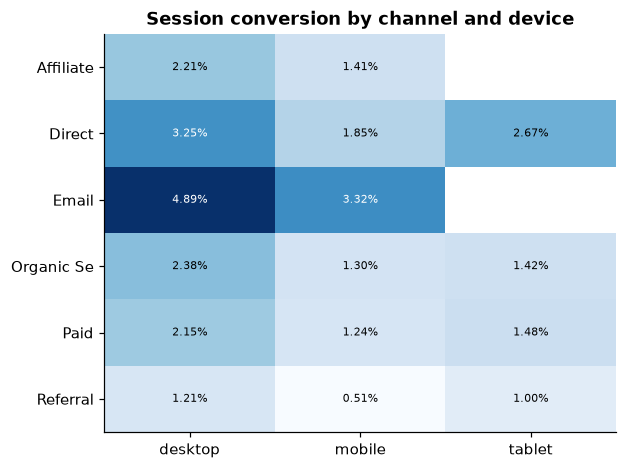

In [18]:
cross = query("""
SELECT channel_group, device_category,
       count(*)                                                AS sessions,
       round(count(*) FILTER (WHERE purchased) / count(*), 4)   AS conversion_rate
FROM fct_funnel
GROUP BY 1, 2
HAVING count(*) > 1000
""").pivot(index="channel_group", columns="device_category", values="conversion_rate")

viz.save(viz.heatmap(cross, "Session conversion by channel and device", fmt="{:.2%}"), "02_channel_device_heatmap")
cross

## Where the funnel work should go

1. Product view to add to cart loses the most sessions in absolute terms, and the loss is concentrated in expensive baskets rather than spread evenly.
2. Cart to checkout is the worst rate in the middle of the funnel and it is worse for new users on paid channels, which is also the traffic the site pays for.
3. The shipping to payment step is the only place where one device is clearly broken rather than just weaker, and mobile is half of all sessions.

Notebook 04 tests each of these properly and turns them into experiments.